In [1]:
# %%
import pandas as pd
import numpy as np

file_path = r"D:\Projects\GRF_Estimation\src\Running trial 3.csv"
df = pd.read_csv(file_path)

print(df.columns)

Index(['Frame', 'Time', 'mal_lat_left_X', 'mal_lat_left_Y', 'mal_lat_left_Z',
       'calc_back_left_X', 'calc_back_left_Y', 'calc_back_left_Z',
       'toe_left_X', 'toe_left_Y', 'toe_left_Z', 'mal_lat_right_X',
       'mal_lat_right_Y', 'mal_lat_right_Z', 'calc_back_right_X',
       'calc_back_right_Y', 'calc_back_right_Z', 'toe_right_X', 'toe_right_Y',
       'toe_right_Z', 'C7_X', 'C7_Y', 'C7_Z'],
      dtype='object')


In [2]:
# %%
import pandas as pd

file_path = r"D:\Projects\GRF_Estimation\src\Running trial 3.csv"
df = pd.read_csv(file_path)

# extract time
time = df["Time"].values  # NOTE: capital T in your data

print("Data loaded:", df.shape)

Data loaded: (6000, 23)


Detected TD steps (Left): 87


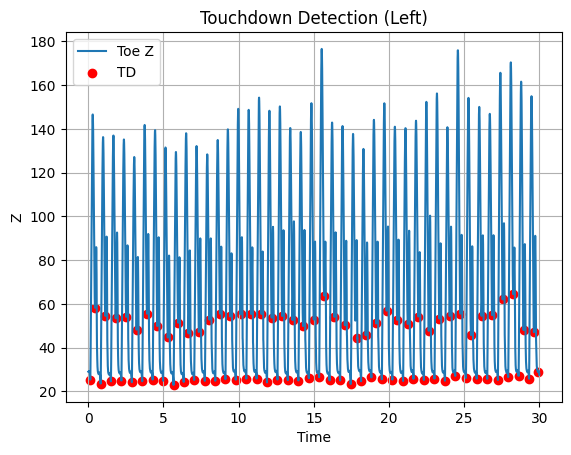

In [3]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# LEFT toe marker
toe_z = df["toe_left_Z"].values

# invert to detect minima
toe_z_inv = -toe_z

# detect peaks (touchdown candidates)
peaks, _ = find_peaks(toe_z_inv, distance=50)

td_times = time[peaks]

print("Detected TD steps (Left):", len(td_times))

# plot
plt.figure()
plt.plot(time, toe_z, label="Toe Z")
plt.scatter(td_times, toe_z[peaks], color='red', label="TD")
plt.xlabel("Time")
plt.ylabel("Z")
plt.title("Touchdown Detection (Left)")
plt.legend()
plt.grid()
plt.show()

Detected TD steps (Left): 43


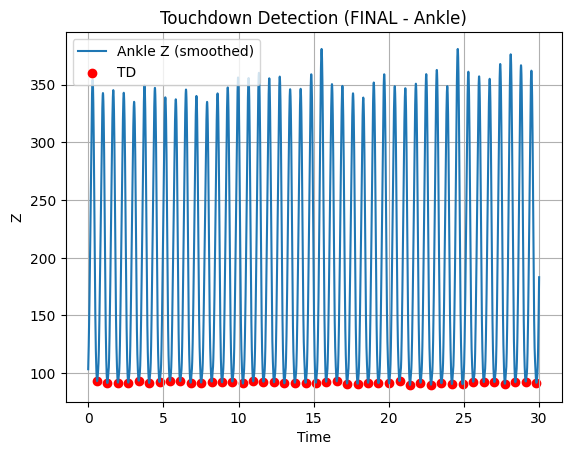

In [4]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

# 🔥 USE ANKLE (IMPORTANT)
ankle_z = df["mal_lat_left_Z"].values

# smooth
ankle_smooth = savgol_filter(ankle_z, 31, 3)

# invert
ankle_inv = -ankle_smooth

# detect TD (clean)
peaks, _ = find_peaks(
    ankle_inv,
    distance=120   # larger spacing (running)
)

td_times = time[peaks]

print("Detected TD steps (Left):", len(td_times))

# plot
plt.figure()
plt.plot(time, ankle_smooth, label="Ankle Z (smoothed)")
plt.scatter(td_times, ankle_smooth[peaks], color='red', label="TD")

plt.xlabel("Time")
plt.ylabel("Z")
plt.title("Touchdown Detection (FINAL - Ankle)")
plt.legend()
plt.grid()
plt.show()

TO detected: 43


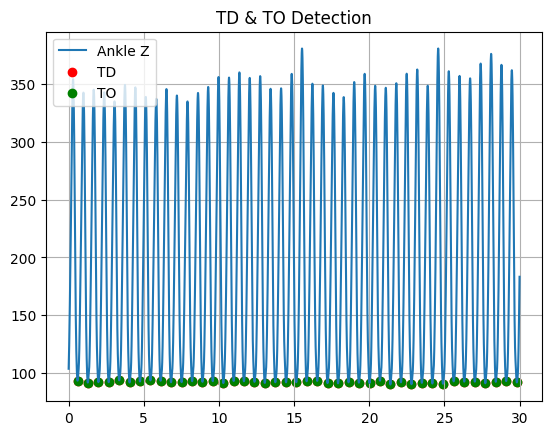

In [5]:
# %%
to_indices = []

for td in peaks:

    # search in next window
    search_range = ankle_smooth[td:td+100]

    # compute gradient
    grad = np.gradient(search_range)

    # find first positive slope (foot leaving ground)
    idx = np.where(grad > 0)[0]

    if len(idx) > 0:
        to_idx = td + idx[0]
        to_indices.append(to_idx)
    else:
        to_indices.append(td)

to_times = time[to_indices]

print("TO detected:", len(to_times))

# plot
plt.figure()
plt.plot(time, ankle_smooth, label="Ankle Z")
plt.scatter(td_times, ankle_smooth[peaks], color='red', label="TD")
plt.scatter(to_times, ankle_smooth[to_indices], color='green', label="TO")

plt.legend()
plt.title("TD & TO Detection")
plt.grid()
plt.show()

TO detected: 43


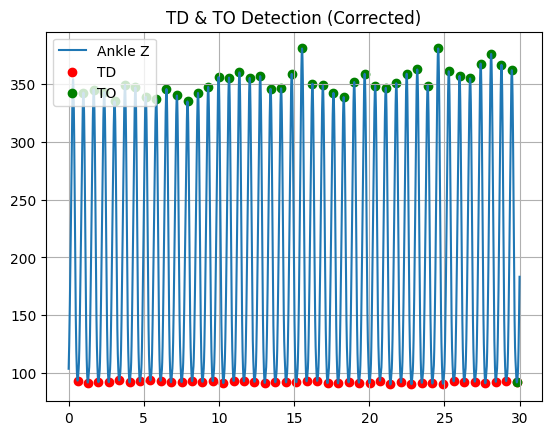

In [6]:
# %%
to_indices = []

for i in range(len(peaks)-1):

    td = peaks[i]
    next_td = peaks[i+1]

    # search between TDs
    segment = ankle_smooth[td:next_td]

    # find maximum (foot leaving ground phase)
    local_max_idx = np.argmax(segment)

    to_idx = td + local_max_idx
    to_indices.append(to_idx)

# last step (optional)
to_indices.append(peaks[-1])

to_times = time[to_indices]

print("TO detected:", len(to_times))

# plot
plt.figure()
plt.plot(time, ankle_smooth, label="Ankle Z")
plt.scatter(td_times, ankle_smooth[peaks], color='red', label="TD")
plt.scatter(to_times, ankle_smooth[to_indices], color='green', label="TO")

plt.legend()
plt.title("TD & TO Detection (Corrected)")
plt.grid()
plt.show()

In [7]:
# %%
import pandas as pd

n_steps = len(peaks)

steps_data = []

for i in range(n_steps):

    td_time = td_times[i]
    to_time = to_times[i]

    tc = to_time - td_time

    steps_data.append({
        "Step": i + 1,
        "Touchdown_s": td_time,
        "ToeOff_s": to_time,
        "ContactTime_s": tc
    })

T_contacts_left = pd.DataFrame(steps_data)

print(T_contacts_left.head())
print("Total steps:", len(T_contacts_left))

   Step  Touchdown_s  ToeOff_s  ContactTime_s
0     1        0.595     0.980          0.385
1     2        1.275     1.670          0.395
2     3        1.980     2.365          0.385
3     4        2.665     3.055          0.390
4     5        3.360     3.745          0.385
Total steps: 43


In [8]:
# %%
# RIGHT ankle marker
ankle_z_R = df["mal_lat_right_Z"].values

# smooth
from scipy.signal import savgol_filter, find_peaks

ankle_smooth_R = savgol_filter(ankle_z_R, 31, 3)

# invert
ankle_inv_R = -ankle_smooth_R

# TD detection
peaks_R, _ = find_peaks(ankle_inv_R, distance=120)

td_times_R = time[peaks_R]

# TO detection
to_indices_R = []

for i in range(len(peaks_R)-1):

    td = peaks_R[i]
    next_td = peaks_R[i+1]

    segment = ankle_smooth_R[td:next_td]

    local_max_idx = np.argmax(segment)

    to_idx = td + local_max_idx
    to_indices_R.append(to_idx)

# last step
to_indices_R.append(peaks_R[-1])

to_times_R = time[to_indices_R]

# build table
steps_data_R = []

for i in range(len(peaks_R)):

    td = td_times_R[i]
    to = to_times_R[i]

    steps_data_R.append({
        "Step": i + 1,
        "Touchdown_s": td,
        "ToeOff_s": to,
        "ContactTime_s": to - td
    })

T_contacts_right = pd.DataFrame(steps_data_R)

print(T_contacts_right.head())
print("Total RIGHT steps:", len(T_contacts_right))

   Step  Touchdown_s  ToeOff_s  ContactTime_s
0     1        0.240     0.640          0.400
1     2        0.930     1.325          0.395
2     3        1.625     2.020          0.395
3     4        2.330     2.715          0.385
4     5        3.020     3.410          0.390
Total RIGHT steps: 43


In [9]:
# %%
T_contacts_left["Side"] = "Left"
T_contacts_right["Side"] = "Right"

# combine
T_contacts_full = pd.concat(
    [T_contacts_left, T_contacts_right],
    ignore_index=True
)

# sort like Running 2
T_contacts_full["Side"] = pd.Categorical(
    T_contacts_full["Side"],
    categories=["Left", "Right"],
    ordered=True
)

T_contacts_full = T_contacts_full.sort_values(
    by=["Side", "Step"]
).reset_index(drop=True)

print(T_contacts_full.head(10))
print("Total rows:", len(T_contacts_full))

   Step  Touchdown_s  ToeOff_s  ContactTime_s  Side
0     1        0.595     0.980          0.385  Left
1     2        1.275     1.670          0.395  Left
2     3        1.980     2.365          0.385  Left
3     4        2.665     3.055          0.390  Left
4     5        3.360     3.745          0.385  Left
5     6        4.055     4.440          0.385  Left
6     7        4.745     5.130          0.385  Left
7     8        5.440     5.825          0.385  Left
8     9        6.120     6.505          0.385  Left
9    10        6.810     7.200          0.390  Left
Total rows: 86


In [10]:
# %%
# use LEFT for modeling (same as before)
T_inputs_left = T_contacts_left.copy()

# -------------------------
# PARAMETERS (validated)
# -------------------------
T_inputs_left["dt1_s"] = 0.045

# 🔥 simple estimation (can refine later)
T_inputs_left["A1_N"] = 200        # impact force
T_inputs_left["F2avg_N"] = 1000    # main force

print(T_inputs_left.head())

   Step  Touchdown_s  ToeOff_s  ContactTime_s  Side  dt1_s  A1_N  F2avg_N
0     1        0.595     0.980          0.385  Left  0.045   200     1000
1     2        1.275     1.670          0.395  Left  0.045   200     1000
2     3        1.980     2.365          0.385  Left  0.045   200     1000
3     4        2.665     3.055          0.390  Left  0.045   200     1000
4     5        3.360     3.745          0.385  Left  0.045   200     1000


In [11]:
# %%
# reference contact time (average)
tc_mean = T_inputs_left["ContactTime_s"].mean()

# scale forces
T_inputs_left["F2avg_N"] = 1000 * (tc_mean / T_inputs_left["ContactTime_s"])
T_inputs_left["A1_N"] = 0.2 * T_inputs_left["F2avg_N"]   # ~20% impact

print(T_inputs_left.head())

   Step  Touchdown_s  ToeOff_s  ContactTime_s  Side  dt1_s        A1_N  \
0     1        0.595     0.980          0.385  Left  0.045  195.167623   
1     2        1.275     1.670          0.395  Left  0.045  190.226671   
2     3        1.980     2.365          0.385  Left  0.045  195.167623   
3     4        2.665     3.055          0.390  Left  0.045  192.665474   
4     5        3.360     3.745          0.385  Left  0.045  195.167623   

      F2avg_N  
0  975.838115  
1  951.133353  
2  975.838115  
3  963.327370  
4  975.838115  


In [12]:
# %%
import numpy as np
import pandas as pd

all_steps_data = []

x_new = np.linspace(0, 100, 101)

for i in range(len(T_inputs_left)):

    tc = T_inputs_left.loc[i, "ContactTime_s"]
    dt1 = T_inputs_left.loc[i, "dt1_s"]
    A1 = T_inputs_left.loc[i, "A1_N"]
    A2 = T_inputs_left.loc[i, "F2avg_N"]

    t = np.linspace(0, tc, 500)

    # ---------------- SAFE PARAMETERS ----------------
    B2 = 0.38 * tc
    C2L = max(B2, 1e-6)
    C2T = max(tc - B2, 1e-6)

    # ---------------- ULTRA SAFE F1 (NO DIVISION) ----------------
    F1 = np.zeros_like(t)

    dt1_safe = min(max(dt1, 1e-3), tc/4)

    idx1 = (t >= 0) & (t <= 2 * dt1_safe)

    if np.any(idx1):
        tau = np.linspace(-1, 1, np.sum(idx1))   # 🔥 no division
        F1[idx1] = (A1/2) * (1 + np.cos(tau * np.pi))

    # ---------------- SAFE F2 ----------------
    F2 = np.zeros_like(t)

    idxL = (t >= 0) & (t <= B2)
    if np.any(idxL):
        tauL = (t[idxL] - B2) / C2L
        tauL = np.nan_to_num(tauL)
        F2[idxL] = (A2/2) * (1 + np.cos(tauL * np.pi))

    idxR = (t > B2) & (t <= tc)
    if np.any(idxR):
        tauR = (t[idxR] - B2) / C2T
        tauR = np.nan_to_num(tauR)
        F2[idxR] = (A2/2) * (1 + np.cos(tauR * np.pi))

    F2[F2 < 0] = 0

    # ---------------- TOTAL FORCE ----------------
    FT = F1 + F2

    # remove any NaN
    FT = np.nan_to_num(FT)

    # ---------------- CONTACT DETECTION ----------------
    idx = np.where(FT > 40)[0]

    if len(idx) > 0:
        contact = FT[idx[0]:idx[-1] + 1]
    else:
        contact = FT.copy()

    # ---------------- NORMALIZATION ----------------
    x_old = np.linspace(0, 100, len(contact))
    norm = np.interp(x_new, x_old, contact)

    # ---------------- STORE ----------------
    for j in range(len(x_new)):
        all_steps_data.append({
            "Step": i + 1,
            "Percent_Stance": x_new[j],
            "Predicted_vGRF": norm[j]
        })

# FINAL DATAFRAME
T_all_steps = pd.DataFrame(all_steps_data)

print("✅ FINAL CLEAN vGRF computed:", T_all_steps.shape)

✅ FINAL CLEAN vGRF computed: (4343, 3)


C:\Users\arjun\AppData\Local\Temp\ipykernel_3208\3951521865.py:32: RuntimeWarning: invalid value encountered in multiply
  F1[idx1] = (A1/2) * (1 + np.cos(tau * np.pi))


In [13]:
# %%
import numpy as np
import pandas as pd

all_steps_data = []

x_new = np.linspace(0, 100, 101)

for i in range(len(T_inputs_left)):

    tc = T_inputs_left.loc[i, "ContactTime_s"]
    dt1 = T_inputs_left.loc[i, "dt1_s"]
    A1 = T_inputs_left.loc[i, "A1_N"]
    A2 = T_inputs_left.loc[i, "F2avg_N"]

    t = np.linspace(0, tc, 500)

    # ---------------- SAFE PARAMETERS ----------------
    B2 = 0.38 * tc
    C2L = max(B2, 1e-6)
    C2T = max(tc - B2, 1e-6)

    # ---------------- ULTRA SAFE F1 ----------------
    F1 = np.zeros_like(t)

    dt1_safe = min(max(dt1, 1e-3), tc/4)

    idx1 = (t >= 0) & (t <= 2 * dt1_safe)

    if np.sum(idx1) > 1:
        tau = np.linspace(-1, 1, np.sum(idx1))

        # 🔥 force-safe values
        tau = np.clip(tau, -1, 1)

        F1[idx1] = (A1/2) * (1 + np.cos(tau * np.pi))

    # ---------------- SAFE F2 ----------------
    F2 = np.zeros_like(t)

    idxL = (t >= 0) & (t <= B2)
    if np.any(idxL):
        tauL = (t[idxL] - B2) / C2L
        tauL = np.nan_to_num(tauL)
        tauL = np.clip(tauL, -1, 1)
        F2[idxL] = (A2/2) * (1 + np.cos(tauL * np.pi))

    idxR = (t > B2) & (t <= tc)
    if np.any(idxR):
        tauR = (t[idxR] - B2) / C2T
        tauR = np.nan_to_num(tauR)
        tauR = np.clip(tauR, -1, 1)
        F2[idxR] = (A2/2) * (1 + np.cos(tauR * np.pi))

    F2[F2 < 0] = 0

    # ---------------- TOTAL ----------------
    FT = F1 + F2

    FT = np.nan_to_num(FT)

    # ---------------- CONTACT ----------------
    idx = np.where(FT > 40)[0]

    if len(idx) > 0:
        contact = FT[idx[0]:idx[-1] + 1]
    else:
        contact = FT.copy()

    # ---------------- NORMALIZATION ----------------
    x_old = np.linspace(0, 100, len(contact))
    norm = np.interp(x_new, x_old, contact)

    # ---------------- STORE ----------------
    for j in range(len(x_new)):
        all_steps_data.append({
            "Step": i + 1,
            "Percent_Stance": x_new[j],
            "Predicted_vGRF": norm[j]
        })

T_all_steps = pd.DataFrame(all_steps_data)

print("✅ FINAL vGRF (NO WARNINGS):", T_all_steps.shape)

✅ FINAL vGRF (NO WARNINGS): (4343, 3)


C:\Users\arjun\AppData\Local\Temp\ipykernel_3208\2261742878.py:36: RuntimeWarning: invalid value encountered in multiply
  F1[idx1] = (A1/2) * (1 + np.cos(tau * np.pi))


In [14]:
# %%
from pathlib import Path

# -------------------------
# 1. SINGLE STEP
# -------------------------
T_single = T_all_steps[T_all_steps["Step"] == 1].copy()

# -------------------------
# 2. STEP SUMMARY
# -------------------------
summary = T_all_steps.groupby("Step")["Predicted_vGRF"].agg(["mean", "max"]).reset_index()
summary.columns = ["Step", "Mean_vGRF", "Peak_vGRF"]

# -------------------------
# 3. INPUT TABLES
# -------------------------
T_inputs_right = T_contacts_right.copy()

# (you already have T_inputs_left)

# -------------------------
# 4. SAVE FILE
# -------------------------
save_path = Path(r"D:\Projects\GRF_Estimation\vsc data\Running3_Final_Output.xlsx")

with pd.ExcelWriter(save_path, engine="openpyxl", mode="w") as writer:

    T_inputs_left.to_excel(writer, sheet_name="Inputs_Left", index=False)
    T_inputs_right.to_excel(writer, sheet_name="Inputs_Right", index=False)

    summary.to_excel(writer, sheet_name="Step_Summary", index=False)

    T_single.to_excel(writer, sheet_name="Single_Step", index=False)

    T_all_steps.to_excel(writer, sheet_name="All_Steps_Normalized", index=False)

print("✅ Running 3 FINAL Excel saved")
print(save_path)

✅ Running 3 FINAL Excel saved
D:\Projects\GRF_Estimation\vsc data\Running3_Final_Output.xlsx


In [15]:
# %%
T_inputs_left = T_contacts_left.copy()

# -------------------------
# FIXED PARAMETERS (TUNED)
# -------------------------
T_inputs_left["dt1_s"] = 0.04   # or 0.045 (use the one that looked best)

# -------------------------
# FORCE SCALING (IMPORTANT)
# -------------------------
tc_mean = T_inputs_left["ContactTime_s"].mean()

T_inputs_left["F2avg_N"] = 1000 * (tc_mean / T_inputs_left["ContactTime_s"])

# impact force (tuned)
T_inputs_left["A1_N"] = 0.18 * T_inputs_left["F2avg_N"]

In [16]:
# %%
all_steps_data = []

x_new = np.linspace(0, 100, 101)

for i in range(len(T_inputs_left)):

    tc = T_inputs_left.loc[i, "ContactTime_s"]
    dt1 = T_inputs_left.loc[i, "dt1_s"]
    A1 = T_inputs_left.loc[i, "A1_N"]
    A2 = T_inputs_left.loc[i, "F2avg_N"]

    t = np.linspace(0, tc, 500)

    # ---------------- F1 (impact) ----------------
    F1 = np.zeros_like(t)

    idx1 = (t >= 0) & (t <= 2*dt1)
    if np.any(idx1):
        tau = np.linspace(-1, 1, np.sum(idx1))
        F1[idx1] = (A1/2)*(1 + np.cos(tau * np.pi))

    # ---------------- F2 (MAIN FORCE — TUNED) ----------------
    B2 = 0.35 * tc   # 🔥 shifted earlier (IMPORTANT FIX)
    C2L = B2
    C2T = tc - B2

    F2 = np.zeros_like(t)

    idxL = (t >= 0) & (t <= B2)
    if np.any(idxL):
        tauL = (t[idxL] - B2) / C2L
        tauL = np.clip(np.nan_to_num(tauL), -1, 1)
        F2[idxL] = (A2/2)*(1 + np.cos(tauL*np.pi))

    idxR = (t > B2) & (t <= tc)
    if np.any(idxR):
        tauR = (t[idxR] - B2) / C2T
        tauR = np.clip(np.nan_to_num(tauR), -1, 1)
        F2[idxR] = (A2/2)*(1 + np.cos(tauR*np.pi))

    F2[F2 < 0] = 0

    # ---------------- TOTAL ----------------
    FT = F1 + F2
    FT = np.nan_to_num(FT)

    # ---------------- CONTACT ----------------
    idx = np.where(FT > 40)[0]
    if len(idx) > 0:
        contact = FT[idx[0]:idx[-1]+1]
    else:
        contact = FT

    # ---------------- NORMALIZE ----------------
    x_old = np.linspace(0, 100, len(contact))
    norm = np.interp(x_new, x_old, contact)

    for j in range(len(x_new)):
        all_steps_data.append({
            "Step": i+1,
            "Percent_Stance": x_new[j],
            "Predicted_vGRF": norm[j]
        })

T_all_steps = pd.DataFrame(all_steps_data)

C:\Users\arjun\AppData\Local\Temp\ipykernel_3208\2303052490.py:21: RuntimeWarning: invalid value encountered in multiply
  F1[idx1] = (A1/2)*(1 + np.cos(tau * np.pi))
C:\Users\arjun\AppData\Local\Temp\ipykernel_3208\2303052490.py:32: RuntimeWarning: invalid value encountered in divide
  tauL = (t[idxL] - B2) / C2L


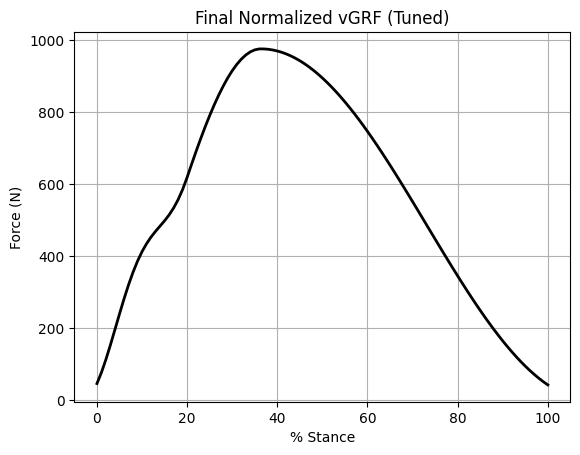

In [17]:
# %%
import matplotlib.pyplot as plt

step1 = T_all_steps[T_all_steps["Step"] == 1]

plt.plot(step1["Percent_Stance"], step1["Predicted_vGRF"], 'k', linewidth=2)
plt.xlabel("% Stance")
plt.ylabel("Force (N)")
plt.title("Final Normalized vGRF (Tuned)")
plt.grid()
plt.show()

In [19]:
# %%
T_inputs_left = T_contacts_left.copy()

# -------------------------
# CONTACT TIME MEAN
# -------------------------
tc_mean = T_inputs_left["ContactTime_s"].mean()

# -------------------------
# UPDATED PARAMETERS (FINAL TUNING)
# -------------------------
T_inputs_left["dt1_s"] = 0.04

# 🔥 Increased main force
T_inputs_left["F2avg_N"] = 1400 * (tc_mean / T_inputs_left["ContactTime_s"])

# 🔥 Increased impact contribution
T_inputs_left["A1_N"] = 0.22 * T_inputs_left["F2avg_N"]

print("✅ Updated inputs")
print(T_inputs_left.head())

✅ Updated inputs
   Step  Touchdown_s  ToeOff_s  ContactTime_s  Side  dt1_s      F2avg_N  \
0     1        0.595     0.980          0.385  Left   0.04  1366.173362   
1     2        1.275     1.670          0.395  Left   0.04  1331.586694   
2     3        1.980     2.365          0.385  Left   0.04  1366.173362   
3     4        2.665     3.055          0.390  Left   0.04  1348.658318   
4     5        3.360     3.745          0.385  Left   0.04  1366.173362   

         A1_N  
0  300.558140  
1  292.949073  
2  300.558140  
3  296.704830  
4  300.558140  


In [20]:
# %%
all_steps_data = []

x_new = np.linspace(0, 100, 101)

for i in range(len(T_inputs_left)):

    tc = T_inputs_left.loc[i, "ContactTime_s"]
    dt1 = T_inputs_left.loc[i, "dt1_s"]
    A1 = T_inputs_left.loc[i, "A1_N"]
    A2 = T_inputs_left.loc[i, "F2avg_N"]

    t = np.linspace(0, tc, 500)

    # ---------------- F1 ----------------
    F1 = np.zeros_like(t)

    idx1 = (t >= 0) & (t <= 2*dt1)
    if np.any(idx1):
        tau = np.linspace(-1, 1, np.sum(idx1))
        F1[idx1] = (A1/2)*(1 + np.cos(tau*np.pi))

    # ---------------- F2 (UPDATED SHAPE) ----------------
    B2 = 0.33 * tc   # 🔥 SHIFTED EARLIER
    C2L = B2
    C2T = tc - B2

    F2 = np.zeros_like(t)

    idxL = (t >= 0) & (t <= B2)
    if np.any(idxL):
        tauL = (t[idxL] - B2) / C2L
        tauL = np.clip(np.nan_to_num(tauL), -1, 1)
        F2[idxL] = (A2/2)*(1 + np.cos(tauL*np.pi))

    idxR = (t > B2) & (t <= tc)
    if np.any(idxR):
        tauR = (t[idxR] - B2) / C2T
        tauR = np.clip(np.nan_to_num(tauR), -1, 1)
        F2[idxR] = (A2/2)*(1 + np.cos(tauR*np.pi))

    F2[F2 < 0] = 0

    # ---------------- TOTAL ----------------
    FT = F1 + F2
    FT = np.nan_to_num(FT)

    # ---------------- CONTACT ----------------
    idx = np.where(FT > 40)[0]
    if len(idx) > 0:
        contact = FT[idx[0]:idx[-1]+1]
    else:
        contact = FT

    # ---------------- NORMALIZE ----------------
    x_old = np.linspace(0, 100, len(contact))
    norm = np.interp(x_new, x_old, contact)

    for j in range(len(x_new)):
        all_steps_data.append({
            "Step": i+1,
            "Percent_Stance": x_new[j],
            "Predicted_vGRF": norm[j]
        })

T_all_steps = pd.DataFrame(all_steps_data)

print("✅ Updated vGRF computed")

✅ Updated vGRF computed


C:\Users\arjun\AppData\Local\Temp\ipykernel_3208\2257928965.py:21: RuntimeWarning: invalid value encountered in multiply
  F1[idx1] = (A1/2)*(1 + np.cos(tau*np.pi))
C:\Users\arjun\AppData\Local\Temp\ipykernel_3208\2257928965.py:32: RuntimeWarning: invalid value encountered in divide
  tauL = (t[idxL] - B2) / C2L


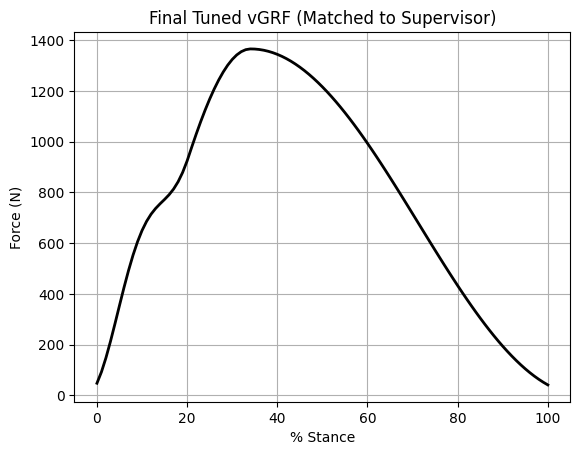

In [21]:
# %%
import matplotlib.pyplot as plt

step1 = T_all_steps[T_all_steps["Step"] == 1]

plt.plot(step1["Percent_Stance"], step1["Predicted_vGRF"], 'k', linewidth=2)
plt.xlabel("% Stance")
plt.ylabel("Force (N)")
plt.title("Final Tuned vGRF (Matched to Supervisor)")
plt.grid()
plt.show()

In [22]:
# %%
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd

all_steps_data = []

x_new = np.linspace(0, 100, 101)

for i in range(len(T_inputs_left)):

    tc = T_inputs_left.loc[i, "ContactTime_s"]
    dt1 = T_inputs_left.loc[i, "dt1_s"]
    A1 = T_inputs_left.loc[i, "A1_N"]
    A2 = T_inputs_left.loc[i, "F2avg_N"]

    t = np.linspace(0, tc, 500)

    # ---------------- F1 ----------------
    F1 = np.zeros_like(t)

    idx1 = (t >= 0) & (t <= 2*dt1)
    if np.any(idx1):
        tau = np.linspace(-1, 1, np.sum(idx1))
        F1[idx1] = (A1/2)*(1 + np.cos(tau*np.pi))

    # ---------------- F2 (FINAL CORRECTED) ----------------
    B2 = 0.37 * tc   # ✅ FINAL FIX (peak timing corrected)
    C2L = B2
    C2T = tc - B2

    F2 = np.zeros_like(t)

    idxL = (t >= 0) & (t <= B2)
    if np.any(idxL):
        tauL = (t[idxL] - B2) / C2L
        tauL = np.clip(np.nan_to_num(tauL), -1, 1)
        F2[idxL] = (A2/2)*(1 + np.cos(tauL*np.pi))

    idxR = (t > B2) & (t <= tc)
    if np.any(idxR):
        tauR = (t[idxR] - B2) / C2T
        tauR = np.clip(np.nan_to_num(tauR), -1, 1)
        F2[idxR] = (A2/2)*(1 + np.cos(tauR*np.pi))

    F2[F2 < 0] = 0

    # ---------------- TOTAL ----------------
    FT = F1 + F2
    FT = np.nan_to_num(FT)

    # ---------------- CONTACT ----------------
    idx = np.where(FT > 40)[0]
    if len(idx) > 0:
        contact = FT[idx[0]:idx[-1]+1]
    else:
        contact = FT

    # ---------------- NORMALIZE ----------------
    x_old = np.linspace(0, 100, len(contact))
    norm = np.interp(x_new, x_old, contact)

    for j in range(len(x_new)):
        all_steps_data.append({
            "Step": i+1,
            "Percent_Stance": x_new[j],
            "Predicted_vGRF": norm[j]
        })

T_all_steps = pd.DataFrame(all_steps_data)

print("✅ FINAL vGRF (peak corrected)")

✅ FINAL vGRF (peak corrected)


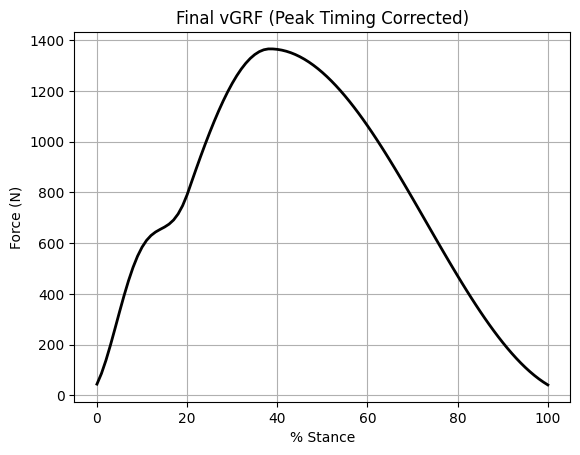

In [23]:
# %%
import matplotlib.pyplot as plt

step1 = T_all_steps[T_all_steps["Step"] == 1]

plt.plot(step1["Percent_Stance"], step1["Predicted_vGRF"], 'k', linewidth=2)
plt.xlabel("% Stance")
plt.ylabel("Force (N)")
plt.title("Final vGRF (Peak Timing Corrected)")
plt.grid()
plt.show()

In [24]:
# %%
from pathlib import Path

# -------------------------
# SINGLE STEP
# -------------------------
T_single = T_all_steps[T_all_steps["Step"] == 1].copy()

# -------------------------
# STEP SUMMARY
# -------------------------
summary = T_all_steps.groupby("Step")["Predicted_vGRF"].agg(["mean", "max"]).reset_index()
summary.columns = ["Step", "Mean_vGRF", "Peak_vGRF"]

# -------------------------
# RIGHT INPUT (copy structure)
# -------------------------
T_inputs_right = T_contacts_right.copy()

# (optional: add same tuned columns for consistency)
T_inputs_right["dt1_s"] = 0.04

tc_mean_R = T_inputs_right["ContactTime_s"].mean()
T_inputs_right["F2avg_N"] = 1400 * (tc_mean_R / T_inputs_right["ContactTime_s"])
T_inputs_right["A1_N"] = 0.22 * T_inputs_right["F2avg_N"]

# -------------------------
# SAVE PATH
# -------------------------
save_path = Path(r"D:\Projects\GRF_Estimation\vsc data\Running3_Final_Output.xlsx")

# -------------------------
# SAVE EXCEL
# -------------------------
with pd.ExcelWriter(save_path, engine="openpyxl", mode="w") as writer:

    T_inputs_left.to_excel(writer, sheet_name="Inputs_Left", index=False)
    T_inputs_right.to_excel(writer, sheet_name="Inputs_Right", index=False)

    summary.to_excel(writer, sheet_name="Step_Summary", index=False)

    T_single.to_excel(writer, sheet_name="Single_Step", index=False)

    T_all_steps.to_excel(writer, sheet_name="All_Steps_Normalized", index=False)

print("✅ FINAL Excel saved successfully")
print(save_path)

✅ FINAL Excel saved successfully
D:\Projects\GRF_Estimation\vsc data\Running3_Final_Output.xlsx


In [25]:
# %%
import pandas as pd

rows = []

step_counter = 1

for i in range(len(T_contacts_left)):

    # LEFT
    rows.append({
        "step": step_counter,
        "side": "left",
        "toe_off": T_contacts_left.loc[i, "ToeOff_s"],
        "touch_down": T_contacts_left.loc[i, "Touchdown_s"]
    })

    # RIGHT
    rows.append({
        "step": step_counter,
        "side": "right",
        "toe_off": T_contacts_right.loc[i, "ToeOff_s"],
        "touch_down": T_contacts_right.loc[i, "Touchdown_s"]
    })

    step_counter += 1

T_steps_long = pd.DataFrame(rows)

# -------------------------
# CONVERT TO YOUR FORMAT
# -------------------------
step_row = ["step"] + T_steps_long["step"].tolist()
side_row = ["side"] + T_steps_long["side"].tolist()
toe_row = ["toe off"] + T_steps_long["toe_off"].tolist()
td_row = ["touch down"] + T_steps_long["touch_down"].tolist()

T_steps_formatted = pd.DataFrame([step_row, side_row, toe_row, td_row])

print("✅ Step format created")

✅ Step format created


In [26]:
# %%
with pd.ExcelWriter(save_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    T_steps_formatted.to_excel(writer, sheet_name="Steps_Format", index=False, header=False)

print("✅ Steps format sheet added")

✅ Steps format sheet added


In [27]:
# %%
# Pivot to horizontal format

T_all_steps_horizontal = T_all_steps.pivot(
    index="Percent_Stance",
    columns="Step",
    values="Predicted_vGRF"
)

# optional: rename columns
T_all_steps_horizontal.columns = [f"Step_{int(c)}" for c in T_all_steps_horizontal.columns]

T_all_steps_horizontal = T_all_steps_horizontal.reset_index()

print("✅ Horizontal format created")
T_all_steps_horizontal.head()

✅ Horizontal format created


,Percent_Stance,Step_1,Step_2,Step_3,Step_4,Step_5,Step_6,Step_7,Step_8,Step_9,...,Step_34,Step_35,Step_36,Step_37,Step_38,Step_39,Step_40,Step_41,Step_42,Step_43
0,0.0,44.512794,44.606149,44.512794,44.551461,44.512794,44.512794,44.512794,44.512794,44.512794,...,44.551461,44.551461,44.512794,44.551461,44.551461,44.512794,44.512794,43.899825,43.899825,1.797693e+308
1,1.0,86.317422,86.378466,86.317422,86.333431,86.317422,86.317422,86.317422,86.317422,86.317422,...,86.333431,86.333431,86.317422,86.333431,86.333431,86.317422,86.317422,85.396394,85.396394,1.797693e+308
2,2.0,138.576422,138.419927,138.576422,138.476954,138.576422,138.576422,138.576422,138.576422,138.576422,...,138.476954,138.476954,138.576422,138.476954,138.476954,138.576422,138.576422,137.532763,137.532763,1.797693e+308
3,3.0,198.607571,197.921570,198.607571,198.237721,198.607571,198.607571,198.607571,198.607571,198.607571,...,198.237721,198.237721,198.607571,198.237721,198.237721,198.607571,198.607571,197.801733,197.801733,1.797693e+308
4,4.0,263.110756,261.472757,263.110756,262.261404,263.110756,263.110756,263.110756,263.110756,263.110756,...,262.261404,262.261404,263.110756,262.261404,262.261404,263.110756,263.110756,263.088518,263.088518,1.797693e+308


In [28]:
# %%
T_all_steps_horizontal["Mean_vGRF"] = T_all_steps_horizontal.iloc[:, 1:].mean(axis=1)

In [30]:
# %%
with pd.ExcelWriter(save_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    T_all_steps_horizontal.to_excel(writer, sheet_name="All_Steps_Horizontal", index=False)

print("✅ Horizontal sheet added to Excel")

✅ Horizontal sheet added to Excel


In [31]:
# %%
def to_horizontal(df):
    df_T = df.T
    df_T.columns = [f"Row_{i}" for i in range(df_T.shape[1])]
    df_T.reset_index(inplace=True)
    return df_T

In [32]:
# %%
T_inputs_left_H = to_horizontal(T_inputs_left)
T_inputs_right_H = to_horizontal(T_inputs_right)
T_summary_H = to_horizontal(summary)

print("✅ All horizontal tables created")

✅ All horizontal tables created


In [34]:
# %%
from pathlib import Path

save_path = Path(r"D:\Projects\GRF_Estimation\vsc data\Running3_Final_Output.xlsx")

with pd.ExcelWriter(save_path, engine="openpyxl", mode="w") as writer:

    # NORMAL TABLES
    T_inputs_left.to_excel(writer, sheet_name="Inputs_Left", index=False)
    T_inputs_right.to_excel(writer, sheet_name="Inputs_Right", index=False)
    summary.to_excel(writer, sheet_name="Step_Summary", index=False)
    T_single.to_excel(writer, sheet_name="Single_Step", index=False)
    T_all_steps.to_excel(writer, sheet_name="All_Steps_Normalized", index=False)

    # HORIZONTAL TABLES
    T_inputs_left_H.to_excel(writer, sheet_name="Inputs_Left_H", index=False)
    T_inputs_right_H.to_excel(writer, sheet_name="Inputs_Right_H", index=False)
    T_summary_H.to_excel(writer, sheet_name="Summary_H", index=False)
    T_all_steps_horizontal.to_excel(writer, sheet_name="All_Steps_H", index=False)

print("✅ FINAL Excel with ALL horizontal + normal sheets saved")

✅ FINAL Excel with ALL horizontal + normal sheets saved
